In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Iris flower dataset
# Features of flower -> dimesions of sepal and petal
# Using flower dimensions find the species of flower

In [3]:
df=pd.read_csv('IRIS.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
data=df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
## Basic Univariate analysis
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
## count of null
data.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [18]:
def cont_univar_analysis(data,col):
  ## non-visual analysis
  series = data[col]
  metrics = series.agg(['count','min','max','mean','median','var','std','skew','kurt']).round(2)
  print("Continuous Data Metrics")
  print(metrics)

  # visual analysis
  sns.histplot(data[col],bins=20,kde=True)
  plt.show()
  sns.boxplot(data[col])
  plt.show()


Continuous Data Metrics
count     150.00
min         4.30
max         7.90
mean        5.84
median      5.80
var         0.69
std         0.83
skew        0.31
kurt       -0.55
Name: sepal_length, dtype: float64


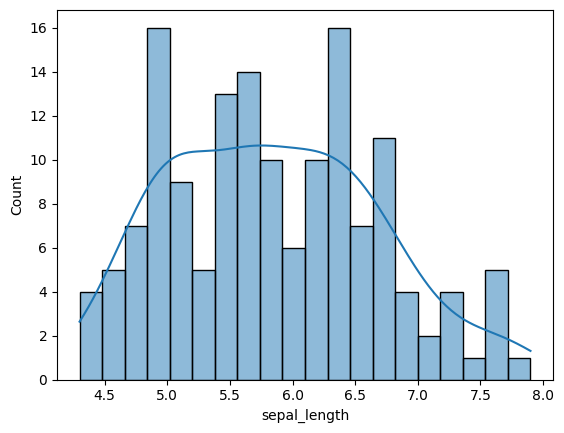

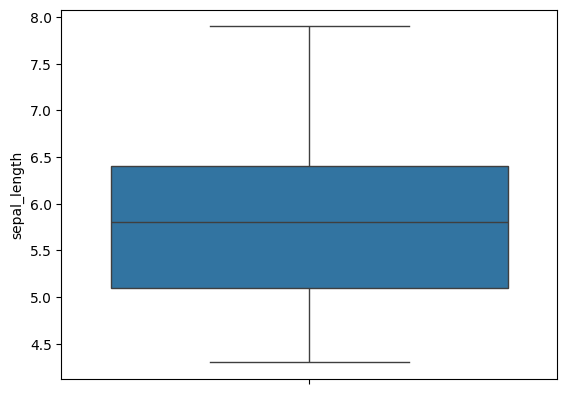

In [19]:
cont_univar_analysis(data,'sepal_length')

Continuous Data Metrics
count     150.00
min         2.00
max         4.40
mean        3.05
median      3.00
var         0.19
std         0.43
skew        0.33
kurt        0.29
Name: sepal_width, dtype: float64


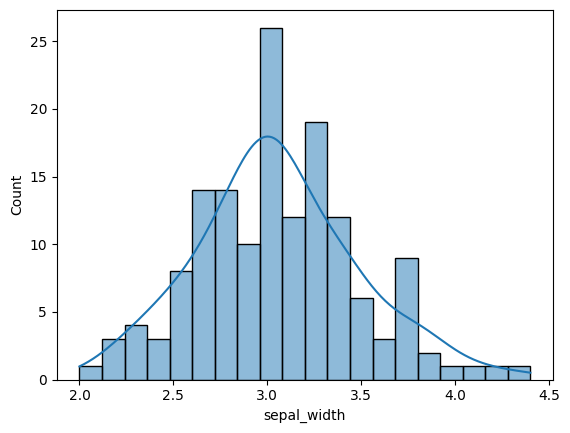

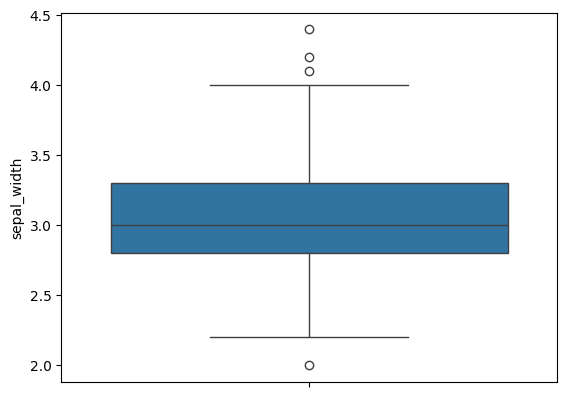

In [20]:
cont_univar_analysis(data,'sepal_width')

Continuous Data Metrics
count     150.00
min         0.10
max         2.50
mean        1.20
median      1.30
var         0.58
std         0.76
skew       -0.10
kurt       -1.34
Name: petal_width, dtype: float64


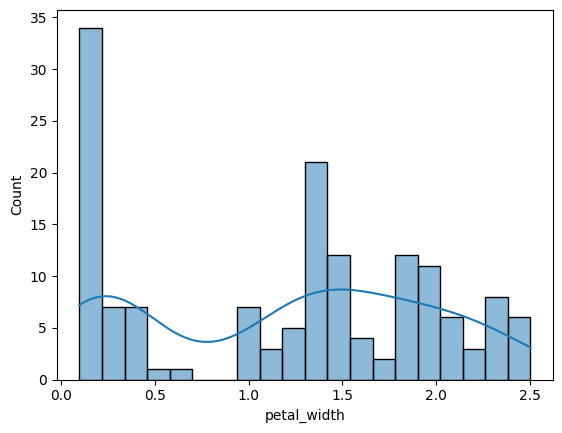

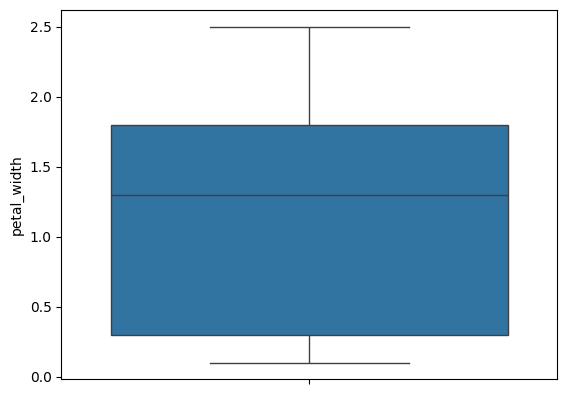

In [21]:
cont_univar_analysis(data,'petal_width')

Continuous Data Metrics
count     150.00
min         1.00
max         6.90
mean        3.76
median      4.35
var         3.11
std         1.76
skew       -0.27
kurt       -1.40
Name: petal_length, dtype: float64


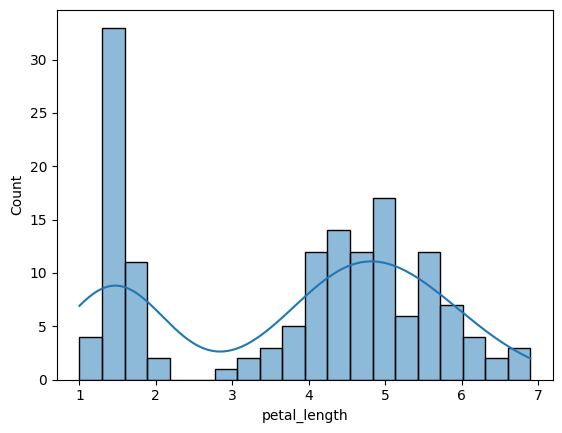

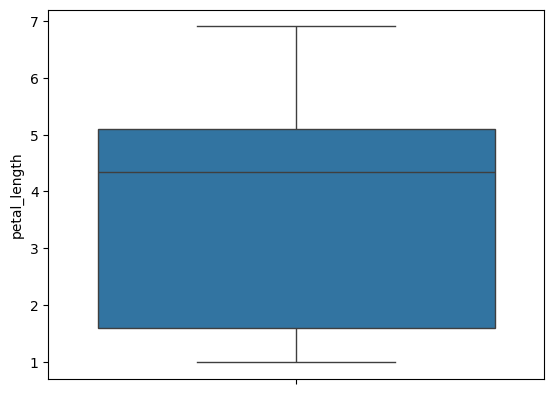

In [22]:
cont_univar_analysis(data,'petal_length')

In [28]:
def cat_univar_analysis(data,col):
  print("Value Counts :")
  value_counts=data[col].value_counts()
  print(value_counts)

  #visual
  sns.countplot(x=col,data=data)
  plt.show()
  plt.pie(value_counts,labels=value_counts.index,autopct='%1.1f%%')
  plt.show()


Value Counts :
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


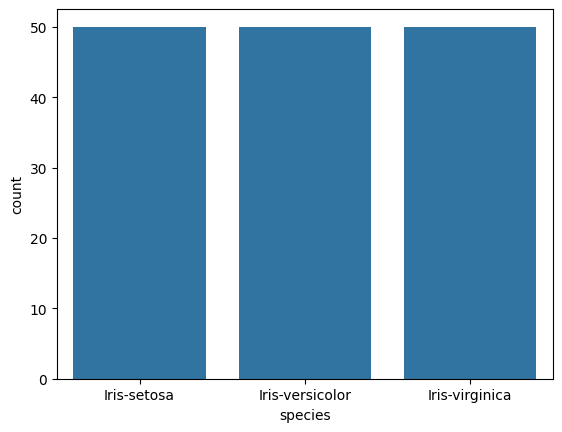

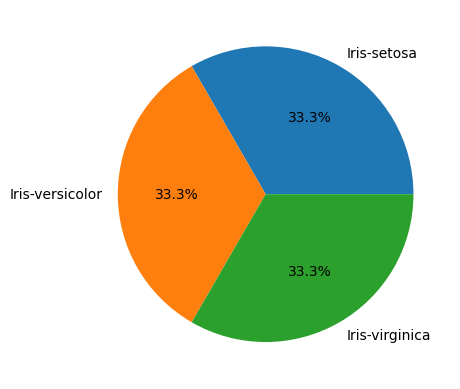

In [29]:
cat_univar_analysis(data,'species')

In [38]:
def cont_cont_bivar(data,col1,col2):
  cov = data[[col1,col2]].cov()
  corr = data[[col1,col2]].corr()

  print("Covariance = ",cov.iloc[0,1])
  print("Correlation = ",corr.iloc[0,1])

  #visual
  sns.scatterplot(x=col1,y=col2,data=data)
  plt.show()

Covariance =  1.2736823266219246
Correlation =  0.8717541573048716


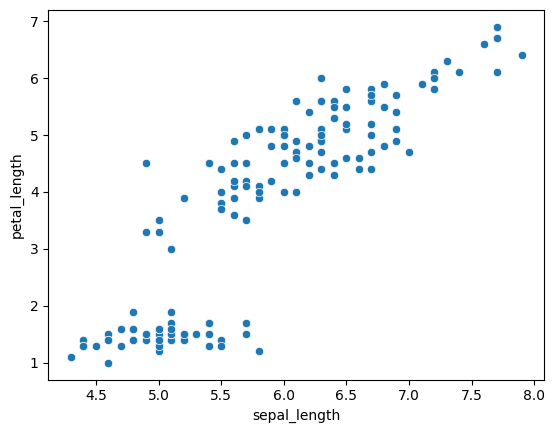

In [39]:
cont_cont_bivar(data,'sepal_length','petal_length')

Covariance =  -0.32171275167785235
Correlation =  -0.4205160964011539


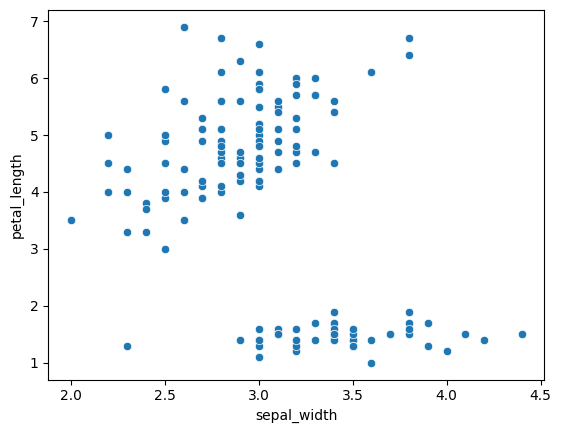

In [40]:
cont_cont_bivar(data,'sepal_width','petal_length')

Covariance =  1.2963874720357944
Correlation =  0.9627570970509662


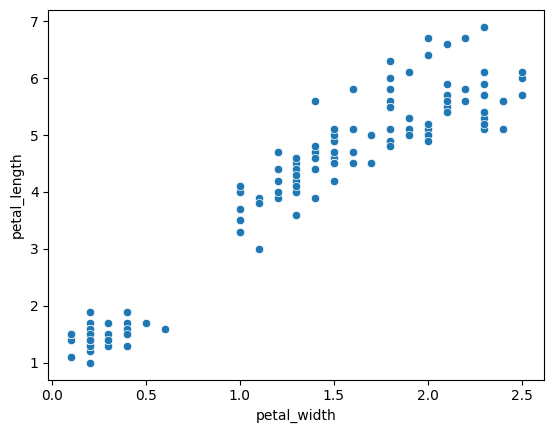

In [41]:
cont_cont_bivar(data,'petal_width','petal_length')

In [45]:
def cont_cat_bivar(data,cont_col,cat_col):
  #non-visual
  metrics = data.groupby(cat_col)[cont_col].agg(['mean','median','min','max'])
  print(metrics)
  #visual
  sns.kdeplot(x=cont_col,data=data,hue=cat_col)
  plt.show()

                  mean  median  min  max
species                                 
Iris-setosa      1.464    1.50  1.0  1.9
Iris-versicolor  4.260    4.35  3.0  5.1
Iris-virginica   5.552    5.55  4.5  6.9


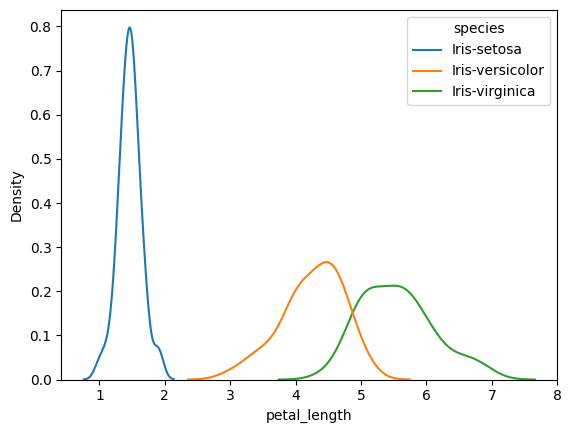

In [46]:
cont_cat_bivar(data,'petal_length','species')

                  mean  median  min  max
species                                 
Iris-setosa      0.244     0.2  0.1  0.6
Iris-versicolor  1.326     1.3  1.0  1.8
Iris-virginica   2.026     2.0  1.4  2.5


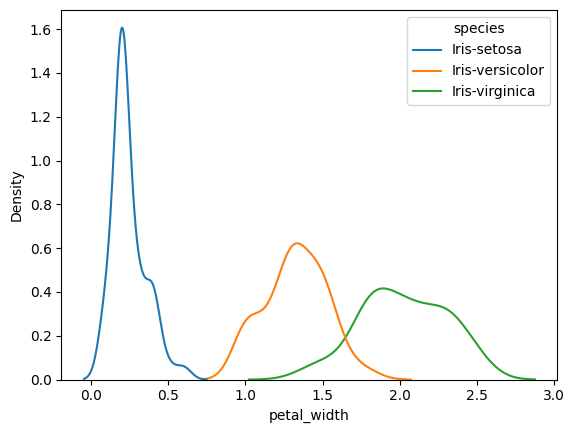

In [47]:
cont_cat_bivar(data,'petal_width','species')

                  mean  median  min  max
species                                 
Iris-setosa      3.418     3.4  2.3  4.4
Iris-versicolor  2.770     2.8  2.0  3.4
Iris-virginica   2.974     3.0  2.2  3.8


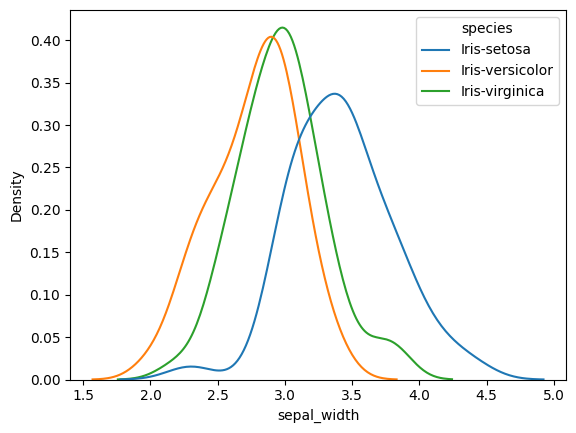

In [48]:
cont_cat_bivar(data,'sepal_width','species')

                  mean  median  min  max
species                                 
Iris-setosa      5.006     5.0  4.3  5.8
Iris-versicolor  5.936     5.9  4.9  7.0
Iris-virginica   6.588     6.5  4.9  7.9


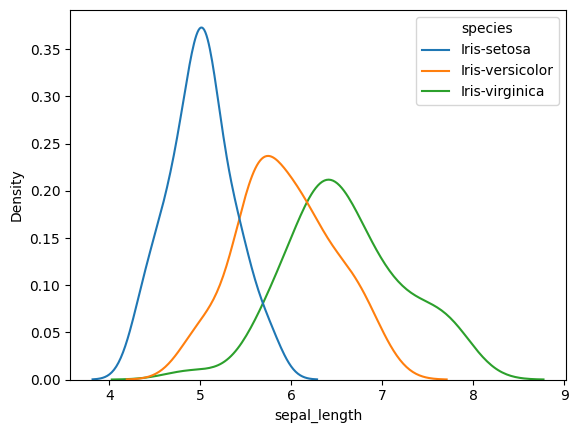

In [49]:
cont_cat_bivar(data,'sepal_length','species')

<Axes: xlabel='sepal_length', ylabel='petal_length'>

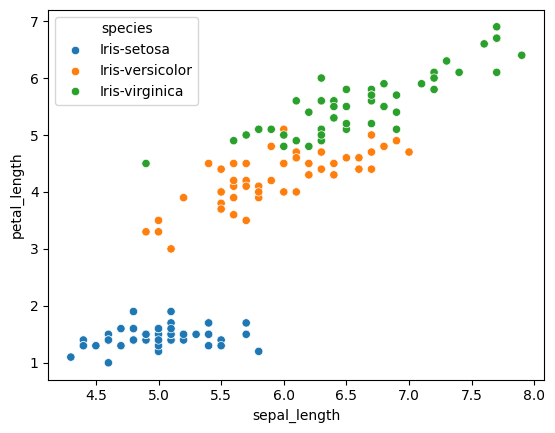

In [52]:
## multivariate analysis
sns.scatterplot(x='sepal_length',y='petal_length',data=data,hue='species')